<a href="https://colab.research.google.com/github/marcomunozq-miaad-uacj/Programacion1Semestre/blob/Programacion1Sem/practica_23_Regresionlasso_ridge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica #23:  Regresionlasso_ridge

Alumno: Marco Antonio Muñoz Quiroz

**Link Github**



### **Instrucciones y Objetivos para la Práctica: Regresión Lasso y Ridge**

#### **📌 Objetivos de la Práctica:**  
Al finalizar esta práctica, los estudiantes serán capaces de:  
1. **Realizar un Análisis Exploratorio de Datos (EDA)** completo, incluyendo visualización de distribuciones, detección de outliers y análisis de correlaciones.  
2. **Preprocesar datos** correctamente, manejando valores faltantes, codificando variables categóricas y escalando características.  
3. **Implementar modelos de regresión Lasso y Ridge**, entendiendo cómo la regularización afecta los coeficientes.  
4. **Verificar los supuestos de la regresión lineal** (linealidad, normalidad de residuos, homocedasticidad y multicolinealidad).  
5. **Comparar el rendimiento** de ambos modelos y analizar qué variables son más relevantes en cada caso.  

---

### **📋 Instrucciones**  

#### **🔹 Paso 1: Configuración Inicial**
✅ Carga el set de datos que puedes encontrar en el campus virtual
✅ Ejecutar las celdas de importación de librerías y carga del dataset.  
✅ Familiarizarse con los datos usando `.head()`, `.info()` y `.describe()`.  

#### **🔹 Paso 2: Análisis Exploratorio (EDA)**  
📊 **Para variables numéricas:**  
- Generar histogramas y boxplots para identificar distribuciones y outliers.  
- Calcular medidas de tendencia central y dispersión.  

📊 **Para variables categóricas:**  
- Usar gráficos de barras para visualizar frecuencias.    

#### **🔹 Paso 3: Matriz de Correlación**  
✅ Calcular la matriz de correlación **solo para variables numéricas**.  
✅ Generar un **mapa de calor** para visualizar relaciones.  
📌 **Pregunta:** ¿Qué variables están más correlacionadas con el target (`charges`)? (salida del dataset)  

#### **🔹 Paso 4: Preprocesamiento**  
🔧 **Tareas:**  
1. Manejar valores faltantes con `SimpleImputer`.  
2. Codificar variables categóricas con `OneHotEncoder`.  
3. Estandarizar variables numéricas con `StandardScaler`.  
✅ Verificar que el dataset transformado no tenga valores nulos.  

#### **🔹 Paso 5: Modelado (Lasso y Ridge)**  
🎯 **Para cada modelo:**  
1. Ajustar el modelo con los hiperparámetros dados (`alpha=0.1` para Lasso, `alpha=1.0` para Ridge).  
2. Calcular **MSE** y **R²** para evaluar rendimiento.  
3. Analizar los coeficientes para identificar variables importantes.  

📌 **Pregunta:**  
- ¿Qué modelo tiene un mejor R²? ¿Por qué crees que ocurre esto?  
- ¿Qué variables tienen coeficientes cercanos a cero en Lasso? ¿Por qué?  

#### **🔹 Paso 6: Verificación de Supuestos**  
📉 **Para cada modelo, verificar:**  
1. **Linealidad** (gráfico de residuos vs predicciones).  
2. **Normalidad de residuos** (QQ-Plot y test de Shapiro-Wilk).  
3. **Homocedasticidad**
4. **Multicolinealidad** (VIF > 10 indica problema).  

📌 **Pregunta:**  
- ¿Se cumplen los supuestos en ambos modelos?  
- Si hay heterocedasticidad, ¿cómo podría solucionarse?  

#### **🔹 Paso 7: Comparación Final**  
📊 **Analizar:**  
- ¿Qué modelo es más interpretable?  
- ¿Cuál reduce mejor el sobreajuste?  
- ¿Qué variables son más importantes en cada caso?  

---

### **📌 Entrega de la Práctica**  
Al finalizar la practica, incluye un texto con los siguientes elementos
- Incluir **comentarios explicativos** en cada paso.  
- Responder las **preguntas planteadas** en celdas Markdown.  

🎯 **Criterios de Evaluación:**  
✔ **Correcto preprocesamiento** (manejo de nulos, escalado, encoding).  
✔ **Análisis visual y estadístico** (gráficos claros, interpretación de resultados).  
✔ **Validación de supuestos** (justificación de si se cumplen o no).  
✔ **Comparación crítica** entre Lasso y Ridge.  

In [88]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [89]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Semestre1/Programacion/Semana11/Practica23/insurance.csv')

In [90]:
def titulo(texto, estilo="doble", mayusculas=True):
    if mayusculas:
        texto = texto.upper()
    bordes = {
        "doble": "═"
    }
    borde = bordes.get(estilo, "-")
    linea = borde * (len(texto) + 8)
    print("\n" + linea)
    print(f"   {texto}   ")
    print(linea + "\n")

In [91]:
import io
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.stats import shapiro, kstest, norm, probplot

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Paso 1: Configuración Inicial

In [92]:
titulo("Primeras filas del dataset")
print(df.head())

titulo("Información del dataset")
buffer = io.StringIO()
df.info(buf=buffer)
print(buffer.getvalue())

titulo("Descripción estadística")
print(df.describe())


══════════════════════════════════
   PRIMERAS FILAS DEL DATASET   
══════════════════════════════════

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

═══════════════════════════════
   INFORMACIÓN DEL DATASET   
═══════════════════════════════

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   objec

# Paso 2: Análisis Exploratorio (EDA)

In [93]:
# Convertir a tipo category
df["sex"] = df["sex"].astype("category")
df["smoker"] = df["smoker"].astype("category")
df["region"] = df["region"].astype("category")

# Crear diccionarios de mapeo de etiquetas
map_sex = dict(enumerate(df["sex"].cat.categories))
map_smoker = dict(enumerate(df["smoker"].cat.categories))
map_region = dict(enumerate(df["region"].cat.categories))

# Mostrar los mapeos
titulo("Mapeos")
print("Mapeo de 'sex':", map_sex)
print("Mapeo de 'smoker':", map_smoker)
print("Mapeo de 'region':", map_region)

# Mostrar tipos de datos
titulo("Tipos de datos")
print(df.dtypes)



══════════════
   MAPEOS   
══════════════

Mapeo de 'sex': {0: 'female', 1: 'male'}
Mapeo de 'smoker': {0: 'no', 1: 'yes'}
Mapeo de 'region': {0: 'northeast', 1: 'northwest', 2: 'southeast', 3: 'southwest'}

══════════════════════
   TIPOS DE DATOS   
══════════════════════

age            int64
sex         category
bmi          float64
children       int64
smoker      category
region      category
charges      float64
dtype: object



═════════════════════════
   HISTOGRAMA DE AGE   
═════════════════════════



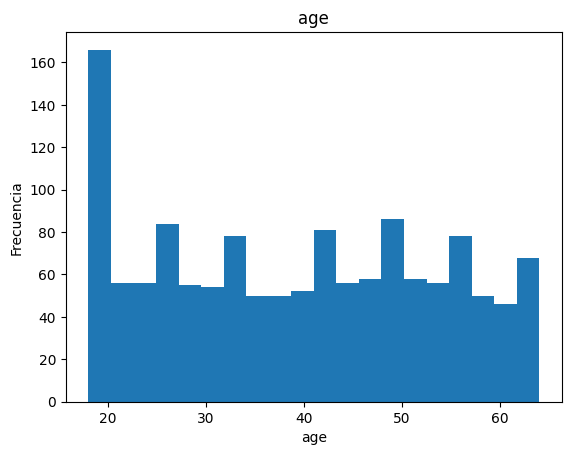


══════════════════════
   BOXPLOT DE AGE   
══════════════════════



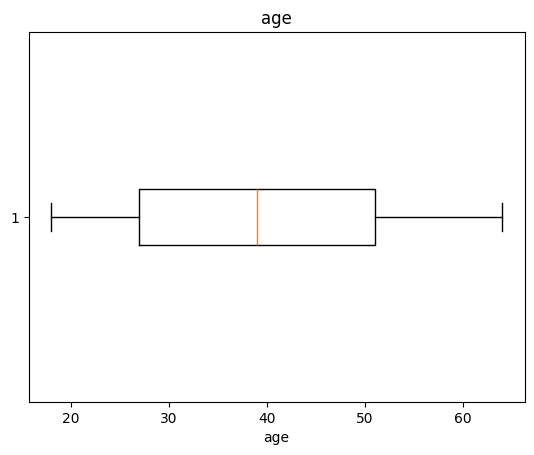


═══════════════════════════════════
   MEDIDAS ESTADÍSTICAS DE AGE   
═══════════════════════════════════

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

══════════════════════════════════
   PRUEBAS DE NORMALIDAD: AGE   
══════════════════════════════════

Shapiro-Wilk -> estadístico=0.9447, p-valor=5.692e-22  |  Rechazo normalidad
Kolmogorov-Smirnov (estandarizado) -> estadístico=0.0790, p-valor=1.024e-07  |  Rechazo normalidad

═══════════════════════
   Q-Q PLOT DE AGE   
═══════════════════════



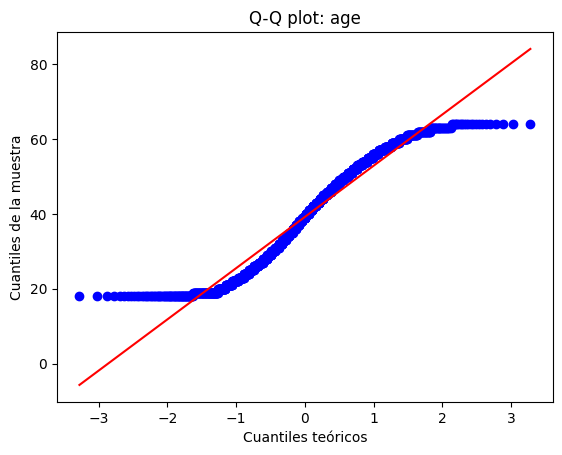


═════════════════════════
   HISTOGRAMA DE BMI   
═════════════════════════



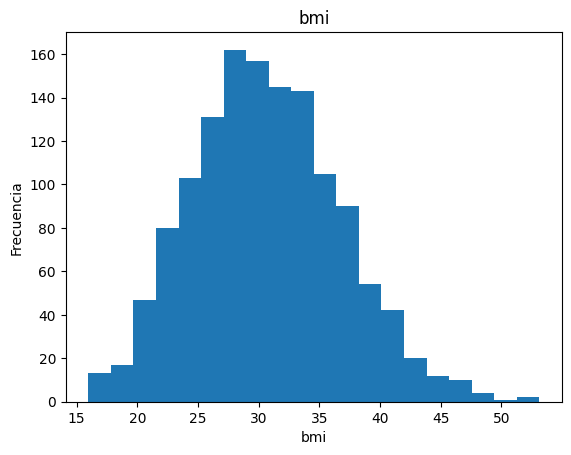


══════════════════════
   BOXPLOT DE BMI   
══════════════════════



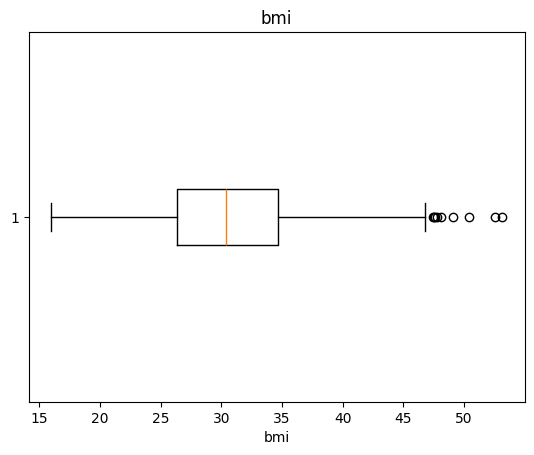


═══════════════════════════════════
   MEDIDAS ESTADÍSTICAS DE BMI   
═══════════════════════════════════

count    1338.000000
mean       30.663397
std         6.098187
min        15.960000
25%        26.296250
50%        30.400000
75%        34.693750
max        53.130000
Name: bmi, dtype: float64

══════════════════════════════════
   PRUEBAS DE NORMALIDAD: BMI   
══════════════════════════════════

Shapiro-Wilk -> estadístico=0.9939, p-valor=2.605e-05  |  Rechazo normalidad
Kolmogorov-Smirnov (estandarizado) -> estadístico=0.0261, p-valor=0.3145  |  No rechazo normalidad

═══════════════════════
   Q-Q PLOT DE BMI   
═══════════════════════



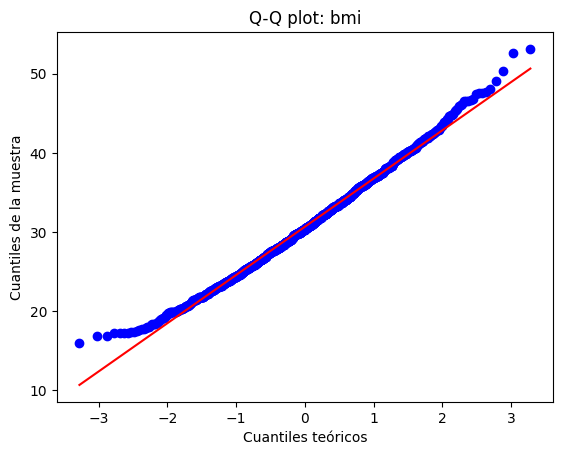


══════════════════════════════
   HISTOGRAMA DE CHILDREN   
══════════════════════════════



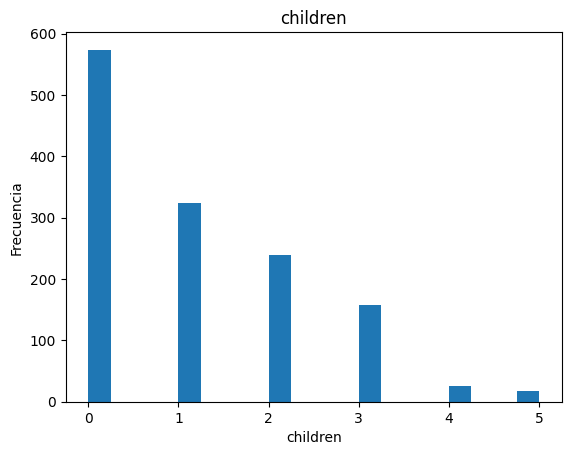


═══════════════════════════
   BOXPLOT DE CHILDREN   
═══════════════════════════



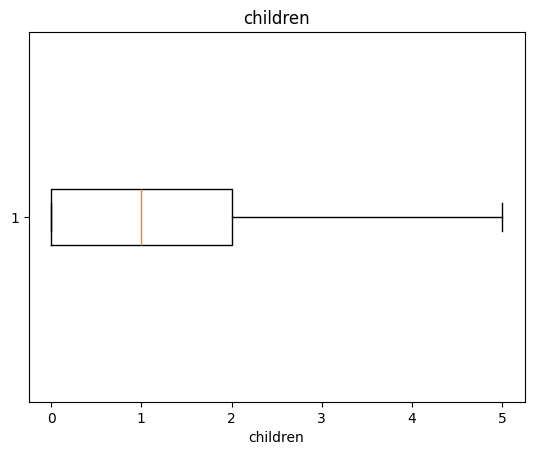


════════════════════════════════════════
   MEDIDAS ESTADÍSTICAS DE CHILDREN   
════════════════════════════════════════

count    1338.000000
mean        1.094918
std         1.205493
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         5.000000
Name: children, dtype: float64

═══════════════════════════════════════
   PRUEBAS DE NORMALIDAD: CHILDREN   
═══════════════════════════════════════

Shapiro-Wilk -> estadístico=0.8232, p-valor=5.066e-36  |  Rechazo normalidad
Kolmogorov-Smirnov (estandarizado) -> estadístico=0.2472, p-valor=1.631e-72  |  Rechazo normalidad

════════════════════════════
   Q-Q PLOT DE CHILDREN   
════════════════════════════



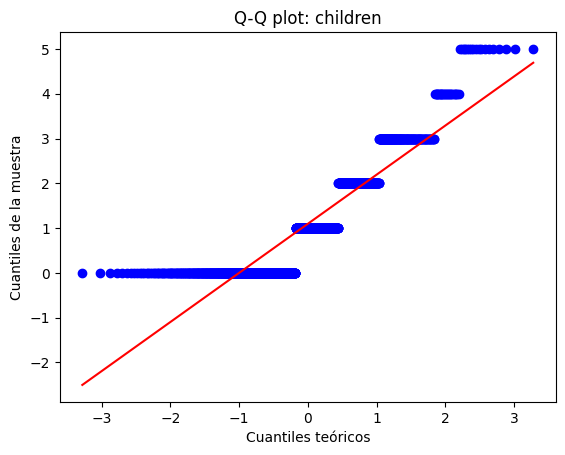


═════════════════════════════
   HISTOGRAMA DE CHARGES   
═════════════════════════════



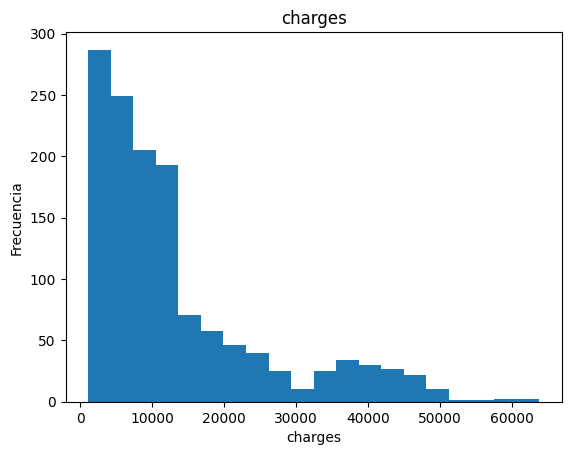


══════════════════════════
   BOXPLOT DE CHARGES   
══════════════════════════



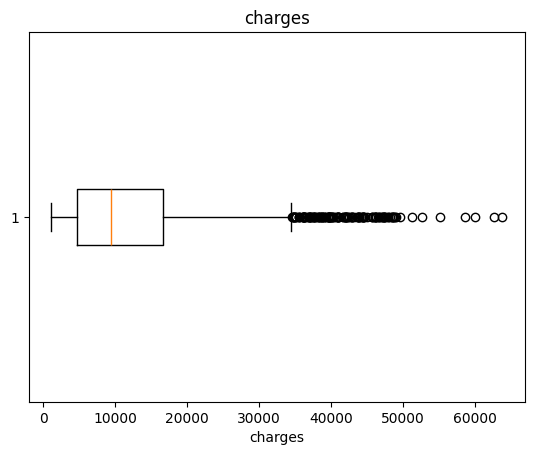


═══════════════════════════════════════
   MEDIDAS ESTADÍSTICAS DE CHARGES   
═══════════════════════════════════════

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

══════════════════════════════════════
   PRUEBAS DE NORMALIDAD: CHARGES   
══════════════════════════════════════

Shapiro-Wilk -> estadístico=0.8147, p-valor=1.151e-36  |  Rechazo normalidad
Kolmogorov-Smirnov (estandarizado) -> estadístico=0.1885, p-valor=4.393e-42  |  Rechazo normalidad

═══════════════════════════
   Q-Q PLOT DE CHARGES   
═══════════════════════════



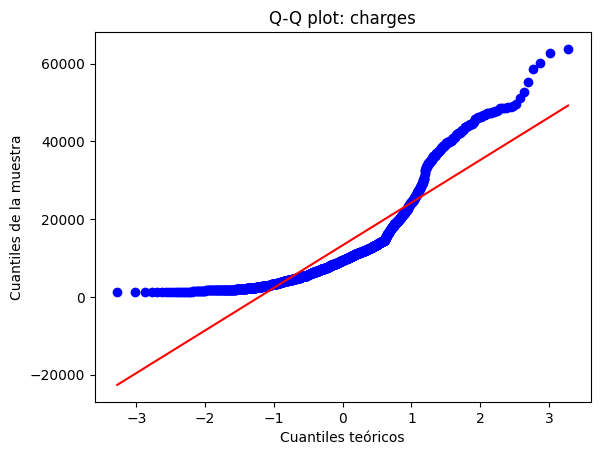


═════════════════════════
   FRECUENCIA DE SEX   
═════════════════════════



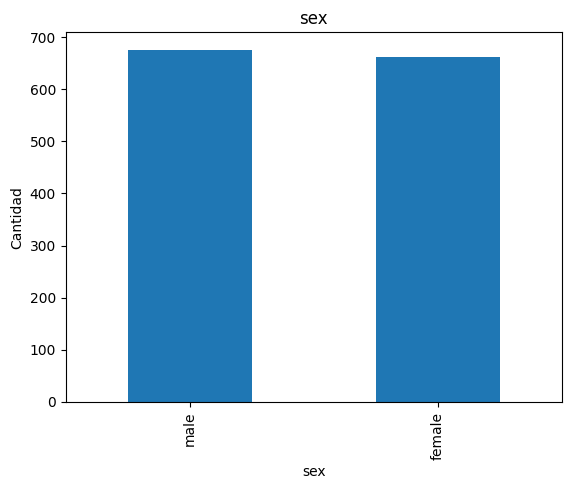


════════════════════════════
   FRECUENCIA DE SMOKER   
════════════════════════════



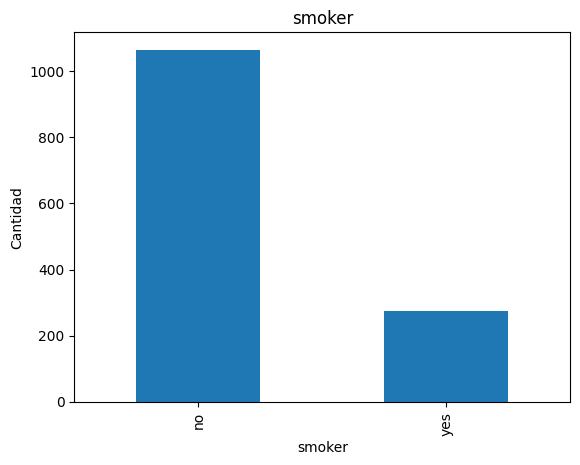


════════════════════════════
   FRECUENCIA DE REGION   
════════════════════════════



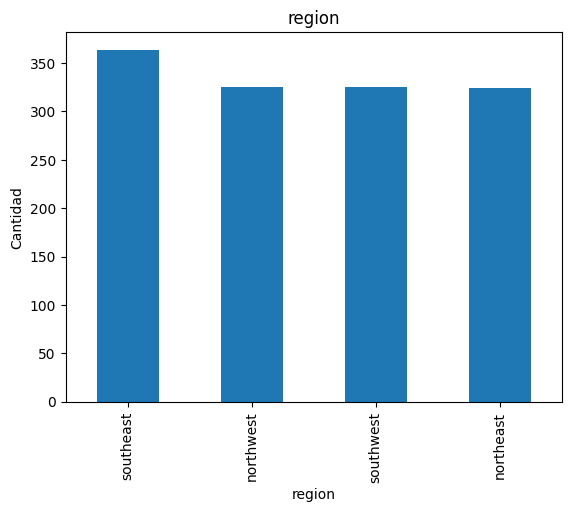


═══════════════════════════════════════════════════
   RESUMEN DE PRUEBAS DE NORMALIDAD (Α = 0.05)   
═══════════════════════════════════════════════════

variable  shapiro_stat    shapiro_p shapiro_decision  ks_stat         ks_p ks_decision  normal_en_ambas
     bmi      0.993886 2.604684e-05          Rechazo 0.026140 3.145398e-01  No rechazo            False
     age      0.944701 5.692047e-22          Rechazo 0.079031 1.024186e-07     Rechazo            False
children      0.823180 5.066437e-36          Rechazo 0.247221 1.631424e-72     Rechazo            False
 charges      0.814688 1.150523e-36          Rechazo 0.188462 4.393057e-42     Rechazo            False

═══════════════════════════════════════
   CONCLUSIÓN RÁPIDA DE NORMALIDAD   
═══════════════════════════════════════

Variables que NO rechazo como normales en ambas pruebas: Ninguna
Variables con evidencia contra la normalidad (al menos una prueba): ['age', 'bmi', 'children', 'charges']


In [94]:
# ======================
# Variables numéricas
# ======================
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
resultados_normalidad = []

for col in num_cols:
    titulo(f"Histograma de {col}")
    plt.hist(df[col], bins=20)
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.title(col)
    plt.show()

    titulo(f"Boxplot de {col}")
    plt.boxplot(df[col], vert=False)
    plt.xlabel(col)
    plt.title(col)
    plt.show()

    titulo(f"Medidas estadísticas de {col}")
    print(df[col].describe())

    serie = df[col].dropna()
    titulo(f"Pruebas de normalidad: {col}")
    stat_sh, p_sh = shapiro(serie)
    z = (serie - serie.mean()) / serie.std(ddof=0)
    stat_ks, p_ks = kstest(z, "norm")

    print(f"Shapiro-Wilk -> estadístico={stat_sh:.4f}, p-valor={p_sh:.4g}  |  {'No rechazo normalidad' if p_sh>=0.05 else 'Rechazo normalidad'}")
    print(f"Kolmogorov-Smirnov (estandarizado) -> estadístico={stat_ks:.4f}, p-valor={p_ks:.4g}  |  {'No rechazo normalidad' if p_ks>=0.05 else 'Rechazo normalidad'}")

    resultados_normalidad.append({
        "variable": col,
        "shapiro_stat": float(stat_sh),
        "shapiro_p": float(p_sh),
        "shapiro_decision": "No rechazo" if p_sh >= 0.05 else "Rechazo",
        "ks_stat": float(stat_ks),
        "ks_p": float(p_ks),
        "ks_decision": "No rechazo" if p_ks >= 0.05 else "Rechazo",
        "normal_en_ambas": (p_sh >= 0.05) and (p_ks >= 0.05)
    })

    titulo(f"Q-Q plot de {col}")
    _ = probplot(serie, dist="norm", plot=plt)
    plt.title(f"Q-Q plot: {col}")
    plt.xlabel("Cuantiles teóricos")
    plt.ylabel("Cuantiles de la muestra")
    plt.show()

# ======================
# Variables categóricas
# ======================
cat_cols = df.select_dtypes(include=["category"]).columns.tolist()

for col in cat_cols:
    titulo(f"Frecuencia de {col}")
    df[col].value_counts().plot(kind="bar")
    plt.xlabel(col)
    plt.ylabel("Cantidad")
    plt.title(col)
    plt.show()

# ======================
# Resumen de normalidad
# ======================
titulo("Resumen de pruebas de normalidad (α = 0.05)")
resumen_norm = pd.DataFrame(resultados_normalidad)

if not resumen_norm.empty:
    cols_mostrar = ["variable", "shapiro_stat", "shapiro_p", "shapiro_decision", "ks_stat", "ks_p", "ks_decision", "normal_en_ambas"]
    print(resumen_norm[cols_mostrar].sort_values(by=["normal_en_ambas","shapiro_p","ks_p"], ascending=[False, False, False]).to_string(index=False))

    normales = resumen_norm[resumen_norm["normal_en_ambas"]]["variable"].tolist()
    no_normales = resumen_norm[~resumen_norm["normal_en_ambas"]]["variable"].tolist()

    titulo("Conclusión rápida de normalidad")
    print("Variables que NO rechazo como normales en ambas pruebas:", normales if normales else "Ninguna")
    print("Variables con evidencia contra la normalidad (al menos una prueba):", no_normales if no_normales else "Ninguna")
else:
    print("No hay resultados de pruebas de normalidad para resumir.")


# Paso 3: Matriz de Correlación


═════════════════════════════════════
   MATRIZ DE CORRELACIÓN (TABLA)   
═════════════════════════════════════

            age    bmi  children  charges
age       1.000  0.109     0.042    0.299
bmi       0.109  1.000     0.013    0.198
children  0.042  0.013     1.000    0.068
charges   0.299  0.198     0.068    1.000

═════════════════════════════════════════════════════════
   MATRIZ DE CORRELACIÓN NUMÉRICA (VALORES ANOTADOS)   
═════════════════════════════════════════════════════════



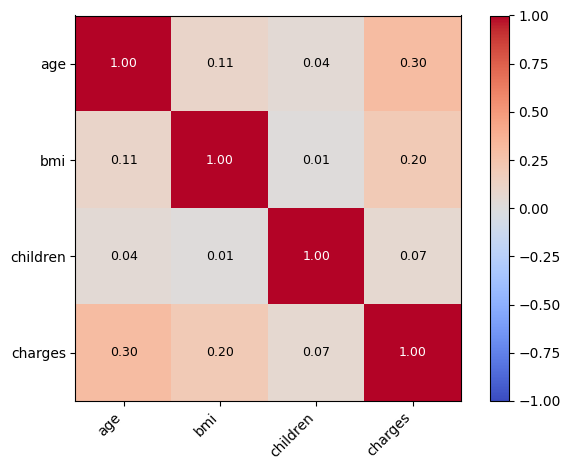


═════════════════════════════════════════════════════════
   CORRELACIONES CON LA VARIABLE CHARGES (ORDENADAS)   
═════════════════════════════════════════════════════════

charges     1.000
age         0.299
bmi         0.198
children    0.068
Name: charges, dtype: float64

═══════════════════════════════════════════════════════════════
   ¿QUÉ VARIABLES ESTÁN MÁS CORRELACIONADAS CON 'CHARGES'?   
═══════════════════════════════════════════════════════════════

age presenta la mayor correlación positiva (0.30) y despues BMI (0.20). A medida que aumenta la edad, y el indice de masa corporal aumentan tienden a aumentar los costos del seguro.


In [95]:
# Matriz de correlación (tabla)
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
corr_matrix = df[num_cols].corr()
titulo("Matriz de correlación (tabla)")
print(corr_matrix.round(3))

# Mapa de calor con valores anotados y nuevo estilo de colores
titulo("Matriz de correlación numérica (valores anotados)")
fig, ax = plt.subplots()
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha="right")
ax.set_yticklabels(num_cols)
plt.colorbar(im, ax=ax)

for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        val = corr_matrix.iat[i, j]
        color = "white" if abs(val) >= 0.5 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=9)

plt.tight_layout()
plt.show()

# Correlaciones con charges ordenadas
titulo("Correlaciones con la variable charges (ordenadas)")
print(corr_matrix["charges"].sort_values(ascending=False).round(3))


titulo("¿Qué variables están más correlacionadas con 'charges'?")
print("age presenta la mayor correlación positiva (0.30) y despues BMI (0.20). A medida que aumenta la edad, y el indice de masa corporal aumentan tienden a aumentar los costos del seguro.")


# Paso 4: Preprocesamiento

In [96]:
# Columnas
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["category", "object"]).columns.tolist()

target_col = "charges"
X = df.drop(columns=[target_col]) if target_col in df.columns else df.copy()
y = df[target_col] if target_col in df.columns else None

# --- Compatibilidad OneHotEncoder (scikit-learn >=1.2 usa sparse_output; <1.2 usa sparse) ---
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", make_ohe())
])

preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipeline, [c for c in num_cols if c in X.columns]),
    ("cat", cat_pipeline, [c for c in cat_cols if c in X.columns]),
], remainder="drop")

X_trans = preprocessor.fit_transform(X)

# Nombres de características
num_presentes = [c for c in num_cols if c in X.columns]
cat_presentes = [c for c in cat_cols if c in X.columns]

cat_feature_names = []
if cat_presentes:
    encoder = preprocessor.named_transformers_["cat"]["encoder"]
    if hasattr(encoder, "get_feature_names_out"):
        cat_feature_names = encoder.get_feature_names_out(cat_presentes).tolist()
    else:  # compatibilidad muy antigua
        cat_feature_names = encoder.get_feature_names(cat_presentes).tolist()

feature_names = num_presentes + cat_feature_names

X_trans_df = pd.DataFrame(X_trans, columns=feature_names, index=df.index)

titulo("Verificación de nulos en el dataset transformado")
total_nulos = int(X_trans_df.isna().sum().sum())
print(f"Número total de valores nulos en X_trans_df: {total_nulos}")
print("¿Sin nulos? ->", "Sí" if total_nulos == 0 else "No")

titulo("Vista previa del dataset transformado")
print(X_trans_df.head())

if y is not None:
    titulo("Shape de features y target")
    print("X_trans_df:", X_trans_df.shape, "| y:", y.shape)



════════════════════════════════════════════════════════
   VERIFICACIÓN DE NULOS EN EL DATASET TRANSFORMADO   
════════════════════════════════════════════════════════

Número total de valores nulos en X_trans_df: 0
¿Sin nulos? -> Sí

═════════════════════════════════════════════
   VISTA PREVIA DEL DATASET TRANSFORMADO   
═════════════════════════════════════════════

        age       bmi  children  sex_female  sex_male  smoker_no  smoker_yes  region_northeast  region_northwest  \
0 -1.438764 -0.453320 -0.908614         1.0       0.0        0.0         1.0               0.0               0.0   
1 -1.509965  0.509621 -0.078767         0.0       1.0        1.0         0.0               0.0               0.0   
2 -0.797954  0.383307  1.580926         0.0       1.0        1.0         0.0               0.0               0.0   
3 -0.441948 -1.305531 -0.908614         0.0       1.0        1.0         0.0               0.0               1.0   
4 -0.513149 -0.292556 -0.908614         0.0   

# Paso 5: Modelado (Lasso y Ridge)



═══════════════════════════════════════════════
   PASO 5: SPLIT DE ENTRENAMIENTO Y PRUEBA   
═══════════════════════════════════════════════

X_train: (1070, 11) | X_test: (268, 11) | y_train: (1070,) | y_test: (268,)

══════════════════════════════════════════════════════
   LASSO (ALPHA=0.1) — ENTRENAMIENTO Y EVALUACIÓN   
══════════════════════════════════════════════════════

MSE: 33597195.70 | R²: 0.7836

═════════════════════════════════════════════════
   COEFICIENTES LASSO (ORDENADOS POR |COEF|)   
═════════════════════════════════════════════════

         feature          coef     abs_coef
       smoker_no -2.365049e+04 2.365049e+04
             age  3.609058e+03 3.609058e+03
             bmi  2.054797e+03 2.054797e+03
region_northeast  6.846628e+02 6.846628e+02
        children  5.123862e+02 5.123862e+02
region_northwest  3.138330e+02 3.138330e+02
region_southwest -1.247138e+02 1.247138e+02
region_southeast  2.662738e+01 2.662738e+01
      sex_female  1.814560e+01 1.814560

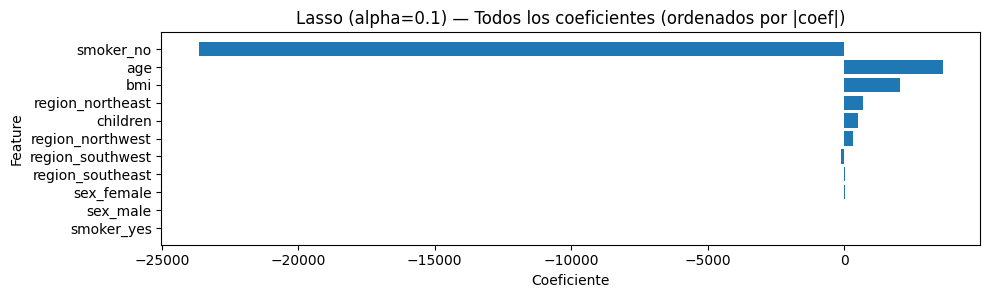


════════════════════════════════════════════
   PESO DE COEFICIENTES — RIDGE (TODOS)   
════════════════════════════════════════════



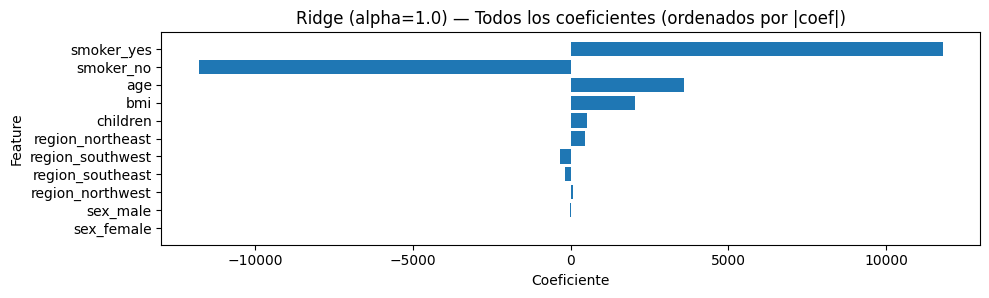

In [97]:
if 'X_trans_df' not in globals() or 'y' not in globals():
    raise RuntimeError("Primero genera X_trans_df e y con el preprocesamiento anterior.")

titulo("Paso 5: Split de entrenamiento y prueba")
X_train, X_test, y_train, y_test = train_test_split(X_trans_df, y, test_size=0.2, random_state=42)
print("X_train:", X_train.shape, "| X_test:", X_test.shape, "| y_train:", y_train.shape, "| y_test:", y_test.shape)

# ===== Lasso =====
titulo("Lasso (alpha=0.1) — entrenamiento y evaluación")
lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
print(f"MSE: {mse_lasso:.2f} | R²: {r2_lasso:.4f}")

coef_lasso = pd.DataFrame({
    "feature": X_train.columns,
    "coef": lasso.coef_,
})
coef_lasso["abs_coef"] = coef_lasso["coef"].abs()
coef_lasso_sorted = coef_lasso.sort_values("abs_coef", ascending=False)

titulo("Coeficientes Lasso (ordenados por |coef|)")
print(coef_lasso_sorted.head(25).to_string(index=False))

# ===== Ridge =====
titulo("Ridge (alpha=1.0) — entrenamiento y evaluación")
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
print(f"MSE: {mse_ridge:.2f} | R²: {r2_ridge:.4f}")

coef_ridge = pd.DataFrame({
    "feature": X_train.columns,
    "coef": ridge.coef_,
})
coef_ridge["abs_coef"] = coef_ridge["coef"].abs()
coef_ridge_sorted = coef_ridge.sort_values("abs_coef", ascending=False)

titulo("Coeficientes Ridge (ordenados por |coef|)")
print(coef_ridge_sorted.head(25).to_string(index=False))

# ===== Resumen comparativo =====
titulo("Resumen comparativo Lasso vs Ridge")
resumen = pd.DataFrame({
    "modelo": ["Lasso(0.1)", "Ridge(1.0)"],
    "MSE": [mse_lasso, mse_ridge],
    "R2": [r2_lasso, r2_ridge]
})
print(resumen.to_string(index=False))

titulo("Variables más importantes según cada modelo")
top_k = 10
top_lasso = coef_lasso_sorted.head(top_k)[["feature","coef"]].reset_index(drop=True)
top_ridge = coef_ridge_sorted.head(top_k)[["feature","coef"]].reset_index(drop=True)
print("Top Lasso:")
print(top_lasso.to_string(index=False))
print("\nTop Ridge:")
print(top_ridge.to_string(index=False))

# Lasso
coef_lasso_all = pd.DataFrame({"feature": X_trans_df.columns, "coef": lasso.coef_})
coef_lasso_all["abs_coef"] = coef_lasso_all["coef"].abs()
coef_lasso_all = coef_lasso_all.sort_values("abs_coef", ascending=False)
titulo("Peso de coeficientes — Lasso (todos)")
h = max(3, 0.28 * len(coef_lasso_all))
plt.figure(figsize=(10, h))
plt.barh(coef_lasso_all["feature"][::-1], coef_lasso_all["coef"][::-1])
plt.xlabel("Coeficiente")
plt.ylabel("Feature")
plt.title("Lasso (alpha=0.1) — Todos los coeficientes (ordenados por |coef|)")
plt.tight_layout()
plt.show()

# Ridge
coef_ridge_all = pd.DataFrame({"feature": X_trans_df.columns, "coef": ridge.coef_})
coef_ridge_all["abs_coef"] = coef_ridge_all["coef"].abs()
coef_ridge_all = coef_ridge_all.sort_values("abs_coef", ascending=False)
titulo("Peso de coeficientes — Ridge (todos)")
h = max(3, 0.28 * len(coef_ridge_all))
plt.figure(figsize=(10, h))
plt.barh(coef_ridge_all["feature"][::-1], coef_ridge_all["coef"][::-1])
plt.xlabel("Coeficiente")
plt.ylabel("Feature")
plt.title("Ridge (alpha=1.0) — Todos los coeficientes (ordenados por |coef|)")
plt.tight_layout()
plt.show()


**¿Qué modelo tiene un mejor R²? ¿Por qué crees que ocurre esto?**

El modelo Lasso tiene un R² ligeramente mayor (0.783591) en comparación con el modelo Ridge (0.783443). Esto indica que Lasso logra explicar una proporción un poco mayor de la variabilidad del costo del seguro (charges).

Este comportamiento sugiere que, en este dataset, no todas las variables aportan valor predictivo de forma significativa. Al aplicar la regularización L1, Lasso elimina el ruido y conserva únicamente las variables más relevantes, lo que mejora ligeramente su capacidad de generalización. En otras palabras, el modelo se beneficia de la selección automática de variables y evita el sobreajuste al reducir coeficientes irrelevantes a cero.

**¿Qué variables tienen coeficientes cercanos a cero en Lasso? ¿Por qué?**

En el modelo Lasso, las variables con coeficientes cercanos a cero son:

*   sex_male (coeficiente ≈ 0)
*   smoker_yes (coeficiente = 0)

Lasso identifica que estas variables tienen una contribución mínima o redundante para predecir charges. En particular:

La variable smoker_yes está representado por la variable smoker_no, que tiene un coeficiente muy grande en sentido opuesto. Por ello, smoker_yes se vuelve redundante y es eliminado automáticamente por el modelo.

La variable sex_male tiene un efecto muy pequeño en comparación con otras variables como edad, IMC o fumar, por lo que Lasso la reduce prácticamente a cero.

# Paso 6: Verificación de Supuestos


════════════════════════════════════════════════════
   LASSO (ALPHA=0.1) — RESIDUOS VS PREDICCIONES   
════════════════════════════════════════════════════



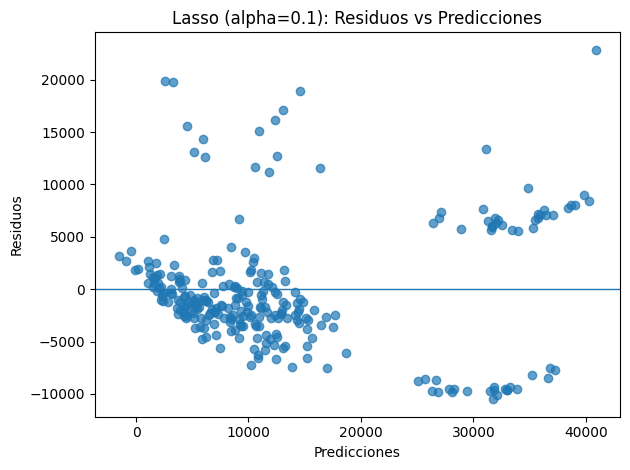


════════════════════════════════════════════
   LASSO (ALPHA=0.1) — QQ-PLOT RESIDUOS   
════════════════════════════════════════════



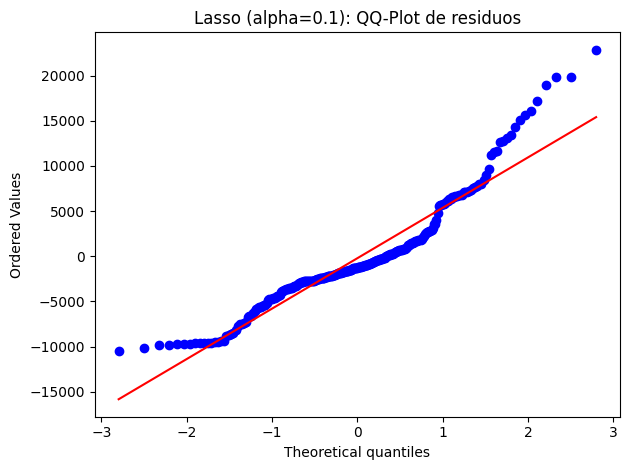


═════════════════════════════════════════════════════════════════
   LASSO (ALPHA=0.1) — NORMALIDAD DE RESIDUOS (SHAPIRO-WILK)   
═════════════════════════════════════════════════════════════════

Shapiro-Wilk: stat=0.9139, p=2.718e-11  |  Rechazo normalidad

════════════════════════════════════════════════════════════
   LASSO (ALPHA=0.1) — HOMOCEDASTICIDAD (BREUSCH-PAGAN)   
════════════════════════════════════════════════════════════

Breusch-Pagan: stat=34.6659, p=0.0002813  |  Evidencia de heterocedasticidad

════════════════════════════════════════════════════
   RIDGE (ALPHA=1.0) — RESIDUOS VS PREDICCIONES   
════════════════════════════════════════════════════



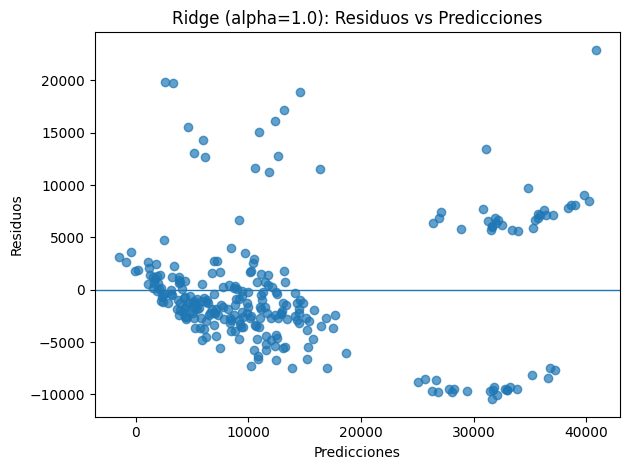


════════════════════════════════════════════
   RIDGE (ALPHA=1.0) — QQ-PLOT RESIDUOS   
════════════════════════════════════════════



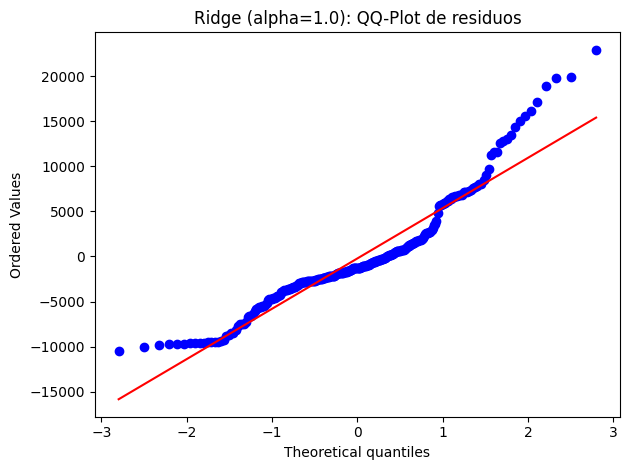


═════════════════════════════════════════════════════════════════
   RIDGE (ALPHA=1.0) — NORMALIDAD DE RESIDUOS (SHAPIRO-WILK)   
═════════════════════════════════════════════════════════════════

Shapiro-Wilk: stat=0.9132, p=2.399e-11  |  Rechazo normalidad

════════════════════════════════════════════════════════════
   RIDGE (ALPHA=1.0) — HOMOCEDASTICIDAD (BREUSCH-PAGAN)   
════════════════════════════════════════════════════════════

Breusch-Pagan: stat=35.0100, p=0.0002469  |  Evidencia de heterocedasticidad

════════════════════════════════════════
   RESUMEN DE SUPUESTOS (P-VALORES)   
════════════════════════════════════════

                      shapiro_p      bp_p
Lasso (alpha=0.1)  2.717761e-11  0.000281
Ridge (alpha=1.0)  2.399417e-11  0.000247

═════════════════════════════════════════════
   MULTICOLINEALIDAD (VIF SOBRE X_TRAIN)   
═════════════════════════════════════════════

         feature      VIF
       smoker_no      inf
        sex_male      inf
      sex_femal

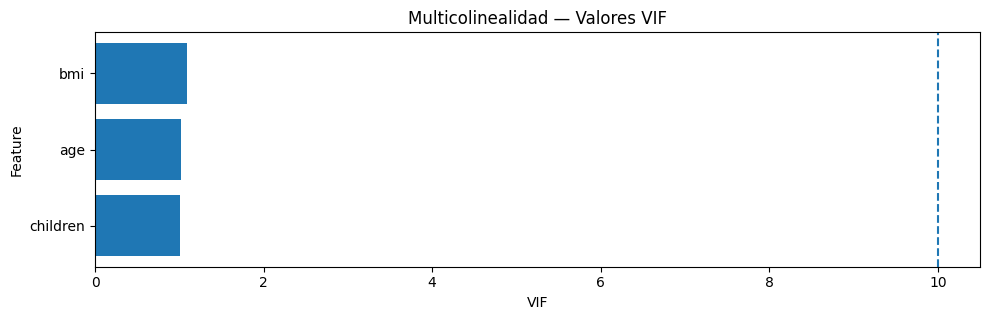

In [98]:
if 'lasso' not in globals() or 'ridge' not in globals():
    raise RuntimeError("Primero entrena Lasso y Ridge (paso 5).")
if 'X_train' not in globals() or 'X_test' not in globals() or 'y_test' not in globals():
    raise RuntimeError("Falta el split de entrenamiento/prueba.")

def eval_modelo(nombre, modelo, X, y):
    y_pred = modelo.predict(X)
    resid = y - y_pred

    titulo(f"{nombre} — Residuos vs Predicciones")
    plt.scatter(y_pred, resid, alpha=0.7)
    plt.axhline(0, linewidth=1)
    plt.xlabel("Predicciones")
    plt.ylabel("Residuos")
    plt.title(f"{nombre}: Residuos vs Predicciones")
    plt.tight_layout()
    plt.show()

    titulo(f"{nombre} — QQ-Plot residuos")
    probplot(resid, dist="norm", plot=plt)
    plt.title(f"{nombre}: QQ-Plot de residuos")
    plt.tight_layout()
    plt.show()

    titulo(f"{nombre} — Normalidad de residuos (Shapiro-Wilk)")
    stat_sh, p_sh = shapiro(resid)
    print(f"Shapiro-Wilk: stat={stat_sh:.4f}, p={p_sh:.4g}  |  {'No rechazo normalidad' if p_sh>=0.05 else 'Rechazo normalidad'}")

    titulo(f"{nombre} — Homocedasticidad (Breusch-Pagan)")
    exog = sm.add_constant(X, has_constant='add')
    bp_stat, bp_p, _, _ = het_breuschpagan(resid, exog)
    print(f"Breusch-Pagan: stat={bp_stat:.4f}, p={bp_p:.4g}  |  {'No rechazo heterocedasticidad (homocedástico)' if bp_p>=0.05 else 'Evidencia de heterocedasticidad'}")

    return pd.Series({"shapiro_p": p_sh, "bp_p": bp_p}, name=nombre)

res_lasso = eval_modelo("Lasso (alpha=0.1)", lasso, X_test, y_test)
res_ridge = eval_modelo("Ridge (alpha=1.0)", ridge, X_test, y_test)

titulo("Resumen de supuestos (p-valores)")
res_sup = pd.concat([res_lasso, res_ridge], axis=1).T
print(res_sup.to_string())

titulo("Multicolinealidad (VIF sobre X_train)")
Xvif = X_train.copy()
Xvif = Xvif.loc[:, Xvif.var() > 0]  # evito columnas constantes
vif_vals = []
for i, col in enumerate(Xvif.columns):
    vif_vals.append({"feature": col, "VIF": variance_inflation_factor(Xvif.values, i)})
vif_df = pd.DataFrame(vif_vals).sort_values("VIF", ascending=False)
print(vif_df.to_string(index=False))

umbral = 10.0
titulo(f"Features con VIF > {umbral}")
altos = vif_df[vif_df["VIF"] > umbral]
print(altos.to_string(index=False) if not altos.empty else "Ninguna feature con VIF problemático.")

# Gráfica de VIF (añadir al final del bloque anterior, después de calcular vif_df)
titulo("Gráfica de VIF por feature")
vif_plot = vif_df.sort_values("VIF", ascending=True)
h = max(3, 0.3 * len(vif_plot))
plt.figure(figsize=(10, h))
plt.barh(vif_plot["feature"], vif_plot["VIF"])
plt.xlabel("VIF")
plt.ylabel("Feature")
plt.title("Multicolinealidad — Valores VIF")
plt.axvline(10, linestyle="--")  # umbral típico
plt.tight_layout()
plt.show()


**¿Se cumplen los supuestos en ambos modelos?**

* Linealidad:

En general, los residuos se distribuyen alrededor de cero, lo que indica que la relación es razonablemente lineal. Sin embargo, en valores altos de charges se nota cierta dispersión, lo que sugiere que la linealidad no es perfecta, pero es aceptable para fines de predicción.

* Normalidad de los residuos:

El QQ-Plot muestra que los residuos no siguen exactamente una distribución normal, especialmente en los extremos. Además, la prueba de Shapiro-Wilk indica que los residuos no son normales. Esto es común en datos reales y no afecta demasiado el rendimiento del modelo, ya que aquí nos interesa más la predicción que la inferencia estadística.

* Homocedasticidad:

Observamos que los residuos no tienen una varianza constante. A medida que aumentan las predicciones, los residuos también se dispersan más. Esto indica heterocedasticidad. Es decir, no se cumple este supuesto.

* Multicolinealidad:

Hay variables categóricas codificadas (como smoker_yes y smoker_no) que están altamente relacionadas entre sí. Esto genera multicolinealidad. El modelo Ridge lo maneja mejor distribuyendo el peso entre ellas, mientras que Lasso directamente elimina una de las dos (dejando su coeficiente en cero).

**Si hay heterocedasticidad, ¿cómo podría solucionarse?**

Podriamos aplicar una transformación logarítmica a la variable objetivo "charges", lo cual ayuda a estabilizar la varianza.

**Conclusión general:**

Los supuestos no se cumplen de forma perfecta, pero los modelos aún son válidos para predicción. Ridge y Lasso manejan bien los problemas de multicolinealidad y siguen siendo adecuados para este tipo de datos

**¿Qué modelo es más interpretable?**

El modelo Lasso es más interpretable porque elimina variables poco relevantes (les asigna coeficiente cero). Esto facilita ver rápidamente qué factores importan y cuáles no.

**¿Cuál reduce mejor el sobreajuste?**

El modelo Ridge suele reducir mejor el sobreajuste porque conserva toda la información y distribuye los coeficientes de forma más equilibrada. Esto lo hace más estable en datos reales. En este proyecto, ambos modelos tuvieron un desempeño muy similar, pero Ridge es ligeramente más robusto.

**¿Qué variables son más importantes en cada caso?**

*El modelo Lasso selecciona solo las variables que tienen un impacto claro y deja en cero las que no aportan valor. Según los coeficientes obtenidos, las variables más importantes son:*

* Fumar (smoker_no con coeficiente muy alto en valor absoluto): indica que fumar aumenta significativamente el costo.
* Edad (age): a medida que aumenta la edad, suben los gastos médicos.
* Índice de masa corporal (bmi): un BMI alto se asocia con mayor riesgo y mayores costos.
* Otras variables que también influyen, aunque en menor medida, son número de hijos (children) y algunas regiones geográficas.
* Variables como sexo (sex_male, sex_female) y smoker_yes fueron prácticamente descartadas porque su efecto adicional es mínimo o redundante.

*El modelo Ridge no elimina variables, sino que ajusta su peso suavemente. Las variables más influyentes también son:*

* Fumar (smoker_yes y smoker_no): sigue siendo el factor más importante.
* Edad (age) y BMI (bmi): mantienen una fuerte influencia.
* Children y región también tienen un efecto, aunque menor.
* Sexo aparece con coeficientes muy pequeños, lo que indica que casi no influye.



# Paso 7: Comparación Final

**¿Qué modelo es más interpretable?**

Lasso. Deja varios coeficientes exactamente en cero (p. ej., sex_male ≈ 0, smoker_yes = 0), así que es más fácil ver qué variables realmente aportan y cuáles no.

**¿Cuál reduce mejor el sobreajuste?**
Ridge. Suele generalizar mejor cuando hay muchas variables con efecto pequeño y colinealidad (como las dummies). En tu proyecto ambos rinden muy parecido, pero Ridge es el más estable por construcción.

**¿Qué variables son más importantes en cada caso?**

Lasso (α=0.1):
* Fumar (quedó representado por smoker_no = −23,650, que implica que fumar aumenta fuertemente charges).
* Edad (age).
* IMC (bmi).

Ridge (α=1.0):

* Fumar (smoker_yes = +11,791, smoker_no = −11,791).
* Edad (age).
* IMC (bmi).




════════════════════════════════════════════════════
   RECTA DE REGRESIÓN FINAL - LASSO (ALPHA=0.1)   
════════════════════════════════════════════════════



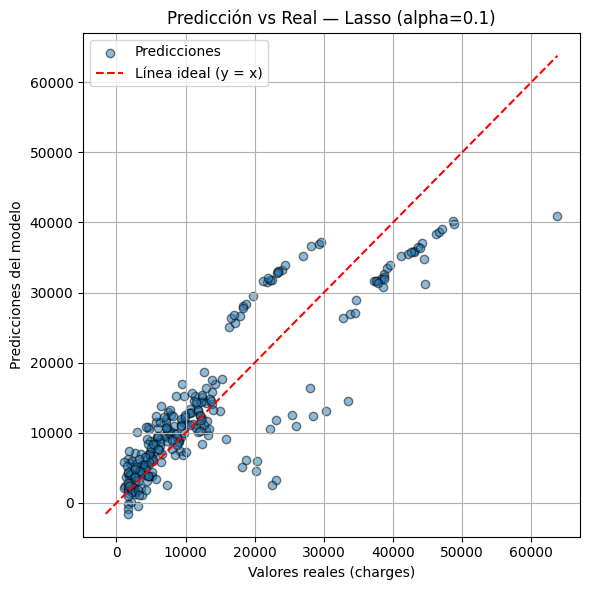


════════════════════════════════════════════════════
   RECTA DE REGRESIÓN FINAL - RIDGE (ALPHA=1.0)   
════════════════════════════════════════════════════



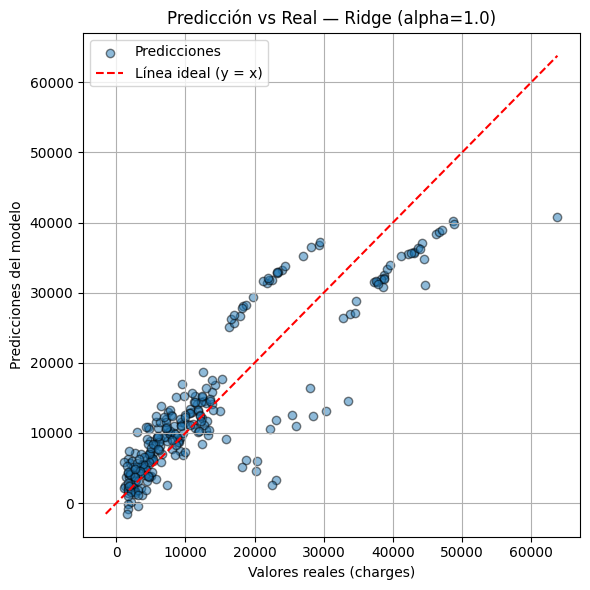

In [99]:
# Predicciones de ambos modelos
y_pred_lasso = lasso.predict(X_test)
y_pred_ridge = ridge.predict(X_test)

# Función para graficar predicciones vs valores reales
def graficar_recta_regresion(y_test, y_pred, nombre_modelo):
    titulo(f"Recta de regresión final - {nombre_modelo}")
    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred, alpha=0.5, label="Predicciones", edgecolors='k')
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    plt.plot(lims, lims, 'r--', label="Línea ideal (y = x)")  # línea de ajuste perfecto
    plt.xlabel("Valores reales (charges)")
    plt.ylabel("Predicciones del modelo")
    plt.title(f"Predicción vs Real — {nombre_modelo}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Graficar para ambos modelos
graficar_recta_regresion(y_test, y_pred_lasso, "Lasso (alpha=0.1)")
graficar_recta_regresion(y_test, y_pred_ridge, "Ridge (alpha=1.0)")



════════════════════════════════════════════════════════════
   COMPARACIÓN DE REGRESIONES: LASSO VS RIDGE VS LINEAL   
════════════════════════════════════════════════════════════



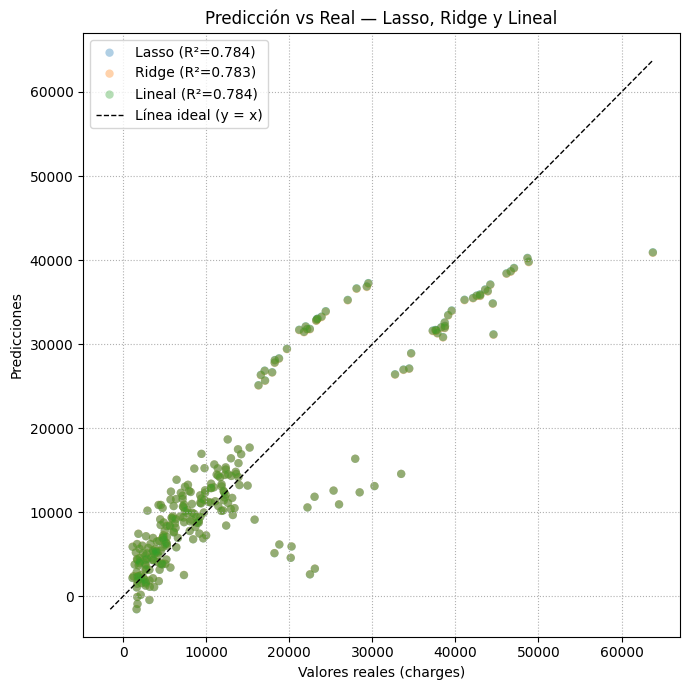

In [100]:
# Aseguro métricas y predicciones previas (si no existen, las calculo)
y_pred_lasso = lasso.predict(X_test)
y_pred_ridge = ridge.predict(X_test)

try:
    r2_lasso
except NameError:
    r2_lasso = r2_score(y_test, y_pred_lasso)
try:
    r2_ridge
except NameError:
    r2_ridge = r2_score(y_test, y_pred_ridge)

# Regresión lineal "normal"
lin = LinearRegression()
lin.fit(X_train, y_train)
y_pred_lin = lin.predict(X_test)
r2_lin = r2_score(y_test, y_pred_lin)

# Gráfica comparativa: valores reales vs. predicciones de los tres modelos
titulo("Comparación de regresiones: Lasso vs Ridge vs Lineal")
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred_lasso, alpha=0.35, label=f"Lasso (R²={r2_lasso:.3f})", edgecolors='none')
plt.scatter(y_test, y_pred_ridge, alpha=0.35, label=f"Ridge (R²={r2_ridge:.3f})", edgecolors='none')
plt.scatter(y_test, y_pred_lin,   alpha=0.35, label=f"Lineal (R²={r2_lin:.3f})",   edgecolors='none')

lims = [min(y_test.min(), y_pred_lasso.min(), y_pred_ridge.min(), y_pred_lin.min()),
        max(y_test.max(), y_pred_lasso.max(), y_pred_ridge.max(), y_pred_lin.max())]
plt.plot(lims, lims, 'k--', linewidth=1, label="Línea ideal (y = x)")

plt.xlabel("Valores reales (charges)")
plt.ylabel("Predicciones")
plt.title("Predicción vs Real — Lasso, Ridge y Lineal")
plt.legend()
plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()


Quise poner las 3 regresiones para comparar si el proceso de ajuste de los pesos de las variables hacia una diferencia pero al menos visualmente no se ve, las 3 rectas de regresion se empalman casi perfectamente. Tal vez ajustando el hiperparametro alfa puedan tenerse rectas de regresion mas "disparejas entre si".

Esperaba ver algo similar a la iamgen de abajo:

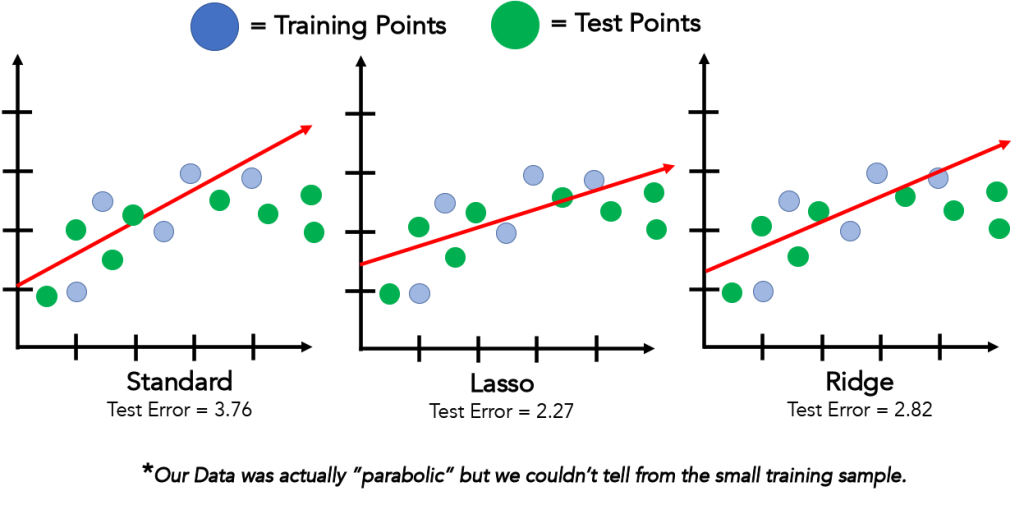